In [1]:
import pandas as pd
import numpy as np
import blinksear as ear
import blinksdistance as distance
import blinkscolors as colors
import json
import matplotlib.pyplot as plt
from pathlib import Path

from blinksear import isBlinkByEar
from blinksdistance import BlinkDistance
from blinkscolors import Colors
from blinkscorrelation import Correlation

In [16]:
def generate_webgazer_dataframe(df):
    df_webgazer = df[~df["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        json_data = df_webgazer["webgazer_data"].iloc[row].replace("'", "\"")
        data_list = json.loads(json_data)
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)

In [29]:
df_local_wg = df_local[~df_local['webgazer_data'].isnull()]
df_local_wg = pd.DataFrame(json.loads(df_local_wg['webgazer_data'].iloc[5]))
df_local_wg

,x,y,t,importantKeypoints,leftEye,rightEye,dz
0,0,0,3,"{'noseX': 338.17, 'noseY': 253.21, 'topY': 170...","{'data': {'0': 52, '1': 40, '2': 25, '3': 255,...","{'data': {'0': 68, '1': 55, '2': 38, '3': 255,...",58.02
1,0,0,38,"{'noseX': 338.2, 'noseY': 253.11, 'topY': 170....","{'data': {'0': 47, '1': 37, '2': 21, '3': 255,...","{'data': {'0': 67, '1': 52, '2': 35, '3': 255,...",59.23
2,0,0,72,"{'noseX': 338.1, 'noseY': 253.07, 'topY': 170....","{'data': {'0': 48, '1': 38, '2': 27, '3': 255,...","{'data': {'0': 69, '1': 54, '2': 33, '3': 255,...",58.44
3,0,0,105,"{'noseX': 338.26, 'noseY': 253.24, 'topY': 170...","{'data': {'0': 46, '1': 38, '2': 22, '3': 255,...","{'data': {'0': 68, '1': 54, '2': 36, '3': 255,...",60.08
4,0,0,139,"{'noseX': 338.45, 'noseY': 253.13, 'topY': 170...","{'data': {'0': 46, '1': 38, '2': 22, '3': 255,...","{'data': {'0': 68, '1': 54, '2': 36, '3': 255,...",58.81
...,...,...,...,...,...,...,...
223,0,0,7584,"{'noseX': 361.32, 'noseY': 259.74, 'topY': 173...","{'data': {'0': 60, '1': 46, '2': 34, '3': 255,...","{'data': {'0': 69, '1': 53, '2': 36, '3': 255,...",66.11
224,0,0,7622,"{'noseX': 361.16, 'noseY': 259.39, 'topY': 173...","{'data': {'0': 60, '1': 47, '2': 32, '3': 255,...","{'data': {'0': 70, '1': 52, '2': 36, '3': 255,...",65.16
225,0,0,7653,"{'noseX': 361.02, 'noseY': 259.52, 'topY': 173...","{'data': {'0': 60, '1': 47, '2': 30, '3': 255,...","{'data': {'0': 67, '1': 52, '2': 35, '3': 255,...",66.11
226,0,0,7687,"{'noseX': 361.42, 'noseY': 259.34, 'topY': 173...","{'data': {'0': 60, '1': 44, '2': 34, '3': 255,...","{'data': {'0': 66, '1': 51, '2': 33, '3': 255,...",64.75


In [3]:
df_local = pd.read_csv("data/blink-experiment-local.csv", encoding="latin1")

df_local_wg = df_local[~df_local['webgazer_data'].isnull()]

df_local_wg = pd.DataFrame(json.loads(df_local_wg['webgazer_data'].iloc[5]))

#df_local_wg['dz'].astype(float).plot()
df_local_wg

,x,y,t,importantKeypoints,leftEye,rightEye,dz
0,0,0,3,"{'noseX': 338.17, 'noseY': 253.21, 'topY': 170...","{'data': {'0': 52, '1': 40, '2': 25, '3': 255,...","{'data': {'0': 68, '1': 55, '2': 38, '3': 255,...",58.02
1,0,0,38,"{'noseX': 338.2, 'noseY': 253.11, 'topY': 170....","{'data': {'0': 47, '1': 37, '2': 21, '3': 255,...","{'data': {'0': 67, '1': 52, '2': 35, '3': 255,...",59.23
2,0,0,72,"{'noseX': 338.1, 'noseY': 253.07, 'topY': 170....","{'data': {'0': 48, '1': 38, '2': 27, '3': 255,...","{'data': {'0': 69, '1': 54, '2': 33, '3': 255,...",58.44
3,0,0,105,"{'noseX': 338.26, 'noseY': 253.24, 'topY': 170...","{'data': {'0': 46, '1': 38, '2': 22, '3': 255,...","{'data': {'0': 68, '1': 54, '2': 36, '3': 255,...",60.08
4,0,0,139,"{'noseX': 338.45, 'noseY': 253.13, 'topY': 170...","{'data': {'0': 46, '1': 38, '2': 22, '3': 255,...","{'data': {'0': 68, '1': 54, '2': 36, '3': 255,...",58.81
...,...,...,...,...,...,...,...
223,0,0,7584,"{'noseX': 361.32, 'noseY': 259.74, 'topY': 173...","{'data': {'0': 60, '1': 46, '2': 34, '3': 255,...","{'data': {'0': 69, '1': 53, '2': 36, '3': 255,...",66.11
224,0,0,7622,"{'noseX': 361.16, 'noseY': 259.39, 'topY': 173...","{'data': {'0': 60, '1': 47, '2': 32, '3': 255,...","{'data': {'0': 70, '1': 52, '2': 36, '3': 255,...",65.16
225,0,0,7653,"{'noseX': 361.02, 'noseY': 259.52, 'topY': 173...","{'data': {'0': 60, '1': 47, '2': 30, '3': 255,...","{'data': {'0': 67, '1': 52, '2': 35, '3': 255,...",66.11
226,0,0,7687,"{'noseX': 361.42, 'noseY': 259.34, 'topY': 173...","{'data': {'0': 60, '1': 44, '2': 34, '3': 255,...","{'data': {'0': 66, '1': 51, '2': 33, '3': 255,...",64.75


In [24]:
file_path = '/Users/agustinpenas/Python-proyects/wg-DataAnalysis/data/all-experiments/all-experiment-expose-points2025-07-09T19_53_26.886Z-anteojos copy.csv'

with open(file_path, 'r', encoding='latin1') as f:
    df_from_dataprue = pd.read_csv(f)



In [5]:
data['experiment_runs'][0].keys()

dict_keys(['subject', 'status', 'records', 'start_date', 'end_date'])

In [6]:
suj_number = 1
text_data = data['experiment_runs'][suj_number]['records'][1]['data']

parsed_data = json.loads(text_data)

df_from_dataprue = pd.DataFrame(parsed_data)

df_from_dataprue.head()

,load_time,trial_type,trial_index,time_elapsed,internal_node_id,jspsych_start_time,success,item_width_mm,item_height_mm,item_width_px,...,rt,item_width_deg,px2deg,win_width_deg,win_height_deg,webgazer_data,webgazer_targets,stimulus,response,events
0,5140.0,webgazer-init-camera,0,42971,0.0-0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,events-tracking-start,1,42973,0.0-1.0,2025-07-14T19:54:17.905Z,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,fullscreen,2,49449,0.0-2.0,NaN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,virtual-chinrest,3,179213,0.0-3.0,NaN,NaN,85.6,53.98,378.0,...,129762.0,9.025711,41.880357,36.675905,20.630197,"[{'x': 0, 'y': 0, 't': 4, 'importantKeypoints'...",{},NaN,NaN,NaN
4,NaN,virtual-chinrest,4,226667,0.0-4.0,NaN,NaN,85.6,53.98,385.0,...,47451.0,9.553204,40.300615,38.113562,21.438879,"[{'x': 0, 'y': 0, 't': 5, 'importantKeypoints'...",{},NaN,NaN,NaN


In [26]:
files = Path("./data").glob("*.csv")

for file in files:
    if "dataframe_blink_16" in str(file):
        df_from_dataprue = pd.read_csv(file)
        #print(df_from_dataprue)


In [ ]:
files = Path("./data").glob("*.csv")

for file in files:
    if "dataframe_blink_15" in str(file):
        df_from_dataprue = pd.read_csv(file)
        #print(df_from_dataprue)

In [27]:
df_dataprue_wg = df_from_dataprue[~df_from_dataprue['webgazer_data'].isnull()]
df_dataprue_wg = generate_webgazer_dataframe(df_dataprue_wg)
df_dataprue_wg


,x,y,t,importantKeypoints,dz,trial
0,0,0,4,"{'noseX': 353.73, 'noseY': 327.65, 'topY': 209...",47.98,1
1,0,0,41,"{'noseX': 353.16, 'noseY': 327.44, 'topY': 209...",48.48,1
2,0,0,74,"{'noseX': 353.2, 'noseY': 327.87, 'topY': 209....",48.51,1
3,0,0,108,"{'noseX': 353.02, 'noseY': 327.3, 'topY': 209....",47.30,1
4,0,0,143,"{'noseX': 352.79, 'noseY': 326.7, 'topY': 209....",47.38,1
...,...,...,...,...,...,...
233,0,0,7946,"{'noseX': 393.8, 'noseY': 317.55, 'topY': 204....",46.75,6
234,0,0,7981,"{'noseX': 393.26, 'noseY': 317.18, 'topY': 204...",47.36,6
235,0,0,8014,"{'noseX': 392.7, 'noseY': 317.35, 'topY': 204....",45.37,6
236,0,0,8048,"{'noseX': 391.94, 'noseY': 317.89, 'topY': 204...",45.99,6


In [12]:
df_dataprue_wg = df_from_dataprue[~df_from_dataprue['webgazer_data'].isnull()]

trial_num = 0
df_dataprue_wg = pd.DataFrame(df_dataprue_wg['webgazer_data'].iloc[trial_num])


df_dataprue_wg['dz'].astype(float).plot()

ValueError: DataFrame constructor not properly called!

In [11]:
df_dataprue_wg

,load_time,trial_type,trial_index,time_elapsed,internal_node_id,jspsych_start_time,success,item_width_mm,item_height_mm,item_width_px,...,item_width_deg,px2deg,win_width_deg,win_height_deg,webgazer_data,webgazer_targets,stimulus,response,events,subject_id
2,NaN,html-keyboard-response,8,342831,0.0-9.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"[{'x': 0, 'y': 0, 't': 3, 'importantKeypoints'...",{},"<div style=""width:50px;height:50px;border-radi...",,NaN,1ccaf4b9-3ff7-4a6a-aa3c-c3bf05df211f
4,NaN,html-keyboard-response,10,366407,0.0-11.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"[{'x': 0, 'y': 0, 't': 2, 'importantKeypoints'...",{},"<div style=""width:50px;height:50px;border-radi...",,NaN,1ccaf4b9-3ff7-4a6a-aa3c-c3bf05df211f
6,NaN,html-keyboard-response,12,399439,0.0-13.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"[{'x': 0, 'y': 0, 't': 4, 'importantKeypoints'...",{},"<div style=""width:50px;height:50px;border-radi...",,NaN,1ccaf4b9-3ff7-4a6a-aa3c-c3bf05df211f
8,NaN,html-keyboard-response,14,418463,0.0-15.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"[{'x': 0, 'y': 0, 't': 2, 'importantKeypoints'...",{},"<div style=""width:50px;height:50px;border-radi...",,NaN,1ccaf4b9-3ff7-4a6a-aa3c-c3bf05df211f
10,NaN,html-keyboard-response,16,445274,0.0-17.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"[{'x': 0, 'y': 0, 't': 3, 'importantKeypoints'...",{},"<div style=""width:50px;height:50px;border-radi...",,NaN,1ccaf4b9-3ff7-4a6a-aa3c-c3bf05df211f
12,NaN,html-keyboard-response,18,464823,0.0-19.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"[{'x': 0, 'y': 0, 't': 4, 'importantKeypoints'...",{},"<div style=""width:50px;height:50px;border-radi...",,NaN,1ccaf4b9-3ff7-4a6a-aa3c-c3bf05df211f


In [9]:
df_dataprue_wg['importantKeypoints'].iloc[1]

{'noseX': 315.52,
 'noseY': 277.68,
 'topY': 178.88,
 'bottomY': 361.35,
 'leftEarX': 393.64,
 'rightearX': 250,
 'rightEyeTopArc': [{'x': 334.69, 'y': 237.51, 'point': 463},
  {'x': 338.96, 'y': 236.26, 'point': 398},
  {'x': 342.77, 'y': 234.99, 'point': 384},
  {'x': 348.06, 'y': 234.68, 'point': 385},
  {'x': 353.16, 'y': 234.9, 'point': 386},
  {'x': 358.21, 'y': 236.01, 'point': 387},
  {'x': 361.65, 'y': 237.14, 'point': 388},
  {'x': 363.67, 'y': 238.12, 'point': 466},
  {'x': 365.34, 'y': 238.82, 'point': 263},
  {'x': 365.99, 'y': 242.61, 'point': 255}],
 'rightEyeBottomArc': [{'x': 334.69, 'y': 237.51, 'point': 463},
  {'x': 336.92, 'y': 239.84, 'point': 341},
  {'x': 340.33, 'y': 241.87, 'point': 256},
  {'x': 345.61, 'y': 243.88, 'point': 252},
  {'x': 351.83, 'y': 244.87, 'point': 253},
  {'x': 357.92, 'y': 244.95, 'point': 254},
  {'x': 362.96, 'y': 244.36, 'point': 339},
  {'x': 365.99, 'y': 242.61, 'point': 255}],
 'leftEyeTopArc': [{'x': 273.6, 'y': 238.47, 'point': 2

In [ ]:
files = Path("./data").glob("*.csv")

for file in files:
    if "blink-experiment-5" in str(file):
        df1 = pd.read_csv(file)
        print(df1)
    if "dataframe_blink_15" in str(file):
        df2 = pd.read_csv(file)
        print(df2)


In [28]:
blinkDistance = distance.BlinkDistance()
blinkColors = Colors()
blinkCorrelations = Correlation()

df_webgazer = df_dataprue_wg.copy()


df_webgazer["isBlinkByEar"] = df_webgazer["importantKeypoints"].map(
    lambda x: isBlinkByEar(
        x["rightEyeTopArc"],
        x["rightEyeBottomArc"],
        x["leftEyeTopArc"],
        x["leftEyeBottomArc"],
    )
)
df_webgazer["isBlinkByDistance"] = df_webgazer["importantKeypoints"].map(
    lambda x: blinkDistance.isBlinkByDistance(
        x["rightEyeTopArc"],
        x["rightEyeBottomArc"],
        x["leftEyeTopArc"],
        x["leftEyeBottomArc"],
    )
)
# df_webgazer["isBlinkColors"] = df_webgazer.apply(
#     lambda row: blinkColors.isBlinkByColors(
#         list(row["leftEye"]["data"].values()), list(row["rightEye"]["data"].values())
#     ),
#     axis=1,
# )


# df_webgazer["isBlinkByCorrelation"] = df_webgazer.apply(
#     lambda row: blinkCorrelations.isBlinkByCorrelation(
#         list(row["leftEye"]["data"].values()), list(row["rightEye"]["data"].values())
#     ),
#     axis=1,
# )


# df_webgazer['isBlinkByEar'] = df_webgazer['importantKeypoints'].map(lambda x: isBlinkByEar(x['rightEyeTopArc'], x['rightEyeBottomArc'], x['leftEyeTopArc'], x['leftEyeBottomArc']))

df_webgazer

,x,y,t,importantKeypoints,dz,trial,isBlinkByEar,isBlinkByDistance
0,0,0,4,"{'noseX': 353.73, 'noseY': 327.65, 'topY': 209...",47.98,1,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
1,0,0,41,"{'noseX': 353.16, 'noseY': 327.44, 'topY': 209...",48.48,1,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
2,0,0,74,"{'noseX': 353.2, 'noseY': 327.87, 'topY': 209....",48.51,1,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
3,0,0,108,"{'noseX': 353.02, 'noseY': 327.3, 'topY': 209....",47.30,1,"[False, False, False, False, False, False, Fal...","[False, False, False, True, False, False, Fals..."
4,0,0,143,"{'noseX': 352.79, 'noseY': 326.7, 'topY': 209....",47.38,1,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
...,...,...,...,...,...,...,...,...
233,0,0,7946,"{'noseX': 393.8, 'noseY': 317.55, 'topY': 204....",46.75,6,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
234,0,0,7981,"{'noseX': 393.26, 'noseY': 317.18, 'topY': 204...",47.36,6,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
235,0,0,8014,"{'noseX': 392.7, 'noseY': 317.35, 'topY': 204....",45.37,6,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
236,0,0,8048,"{'noseX': 391.94, 'noseY': 317.89, 'topY': 204...",45.99,6,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."


In [20]:
df_webgazer['isBlinkByEar'].value_counts()

isBlinkByEar
[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]    1416
[False, False, False, False, False, False, False, True, True, True, True, True, True, True, True, True, True, True]                197
[False, False, False, False, False, False, False, False, False, True, True, True, True, True, True, True, True, True]               86
[False, False, False, False, False, False, True, True, True, True, True, True, True, True, True, True, True, True]                  59
[False, False, False, False, False, False, False, False, True, True, True, True, True, True, True, True, True, True]                58
[False, False, False, False, False, False, False, False, False, False, False, True, True, True, True, True, True, True]             47
[False, False, False, False, False, False, False, False, False, False, True, True, True, True, True, True, True, True]              45
[False, False, False, False, False, True, 

In [12]:
df_webgazer['isBlinkByDistance'].value_counts()

isBlinkByDistance
[False, False, False, True, False, False, False, False, False, False, False, False, False, False, False]     1842
[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]    1543
[False, False, True, True, False, False, False, False, False, False, False, False, False, False, False]       163
[False, False, True, True, True, True, True, True, True, True, True, True, True, True, True]                   48
[False, False, True, True, False, False, False, False, False, True, False, False, False, False, False]         41
[False, False, True, True, False, False, False, True, True, True, False, False, True, True, True]              14
[False, False, True, True, False, False, False, False, True, True, False, False, False, False, True]           12
[False, False, True, True, False, True, True, True, True, True, True, True, True, True, True]                   8
[False, False, True, True, False, False, False, True, True, True, Fals

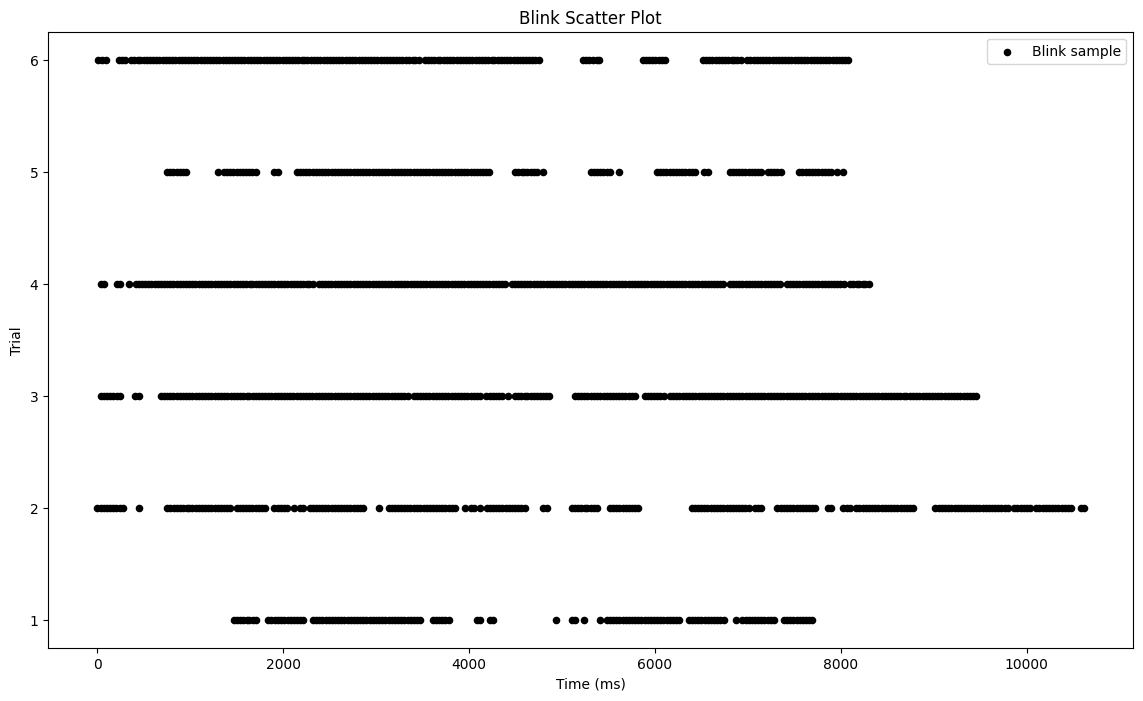

In [29]:
# Define the conditions for the different blink types
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByEar"].apply(lambda x: any(x))

# Initialize the plot
plt.figure(figsize=(14, 8))

# Plot the blink data using different colors for each type
plt.scatter(
    df_webgazer[df_webgazer["Blink_sample"]].t,
    df_webgazer[df_webgazer["Blink_sample"]].trial,
    color="black",
    label="Blink sample",
    s=20,
)

# Add labels and legend
plt.title("Blink Scatter Plot")
plt.xlabel("Time (ms)")
plt.ylabel("Trial")
plt.legend(loc="upper right")

# Show plot
plt.show()


In [21]:
df_webgazer["Blink_sample3_diff"] = df_webgazer["Blink_sample3"].diff()
#df_webgazer.groupby("trial")["Blink_sample3_diff"].sum()

df_webgazer["blinks"] = df_webgazer[df_webgazer['trial']==1].groupby("Blink_sample3_diff")["Blink_sample3_diff"].aggregate("count")
df_webgazer["blinks"]
#df_webgazer["Blink_sample3_diff"].groupby(["trial"]).transform('size')

KeyError: 'Blink_sample3'

/var/folders/bc/dx7gzw5x0d9_snwy574lpzc40000gn/T/ipykernel_1012/548237019.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


<Figure size 1400x800 with 0 Axes>

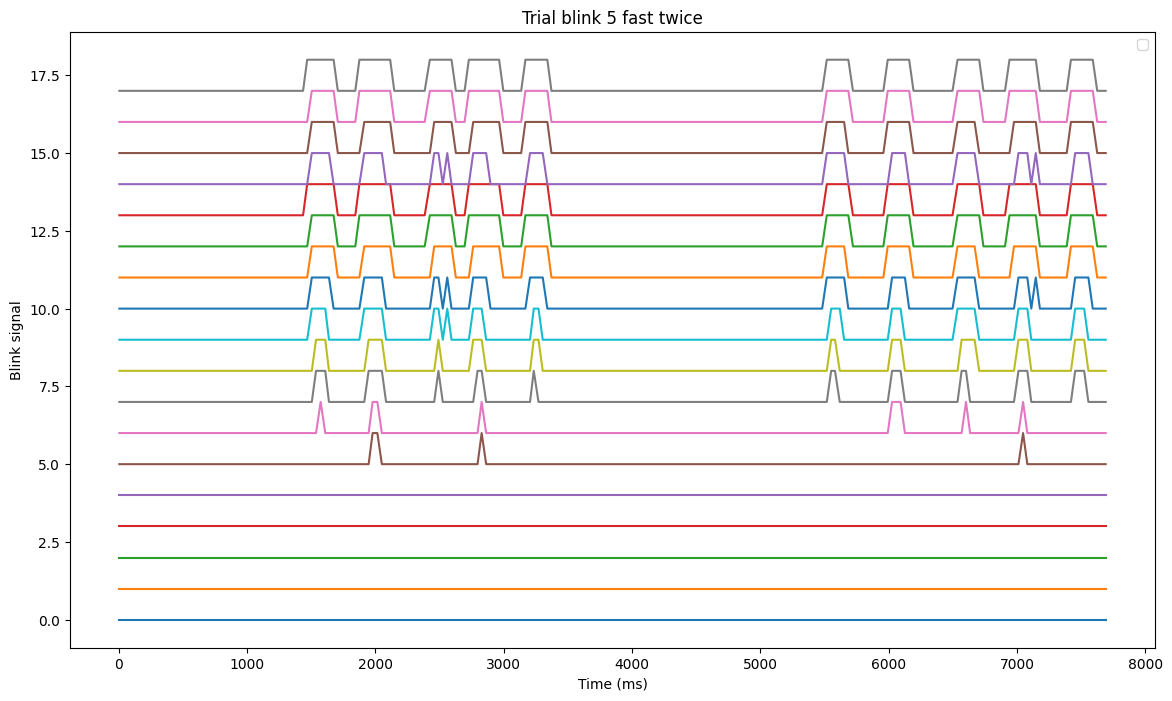

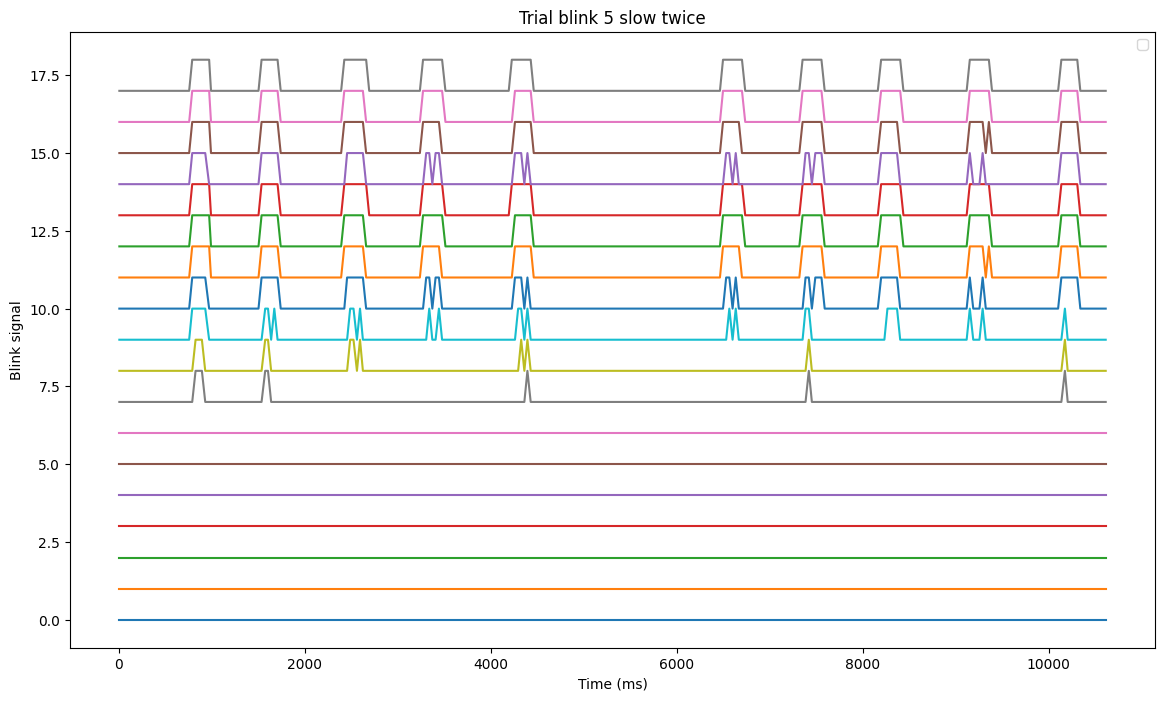

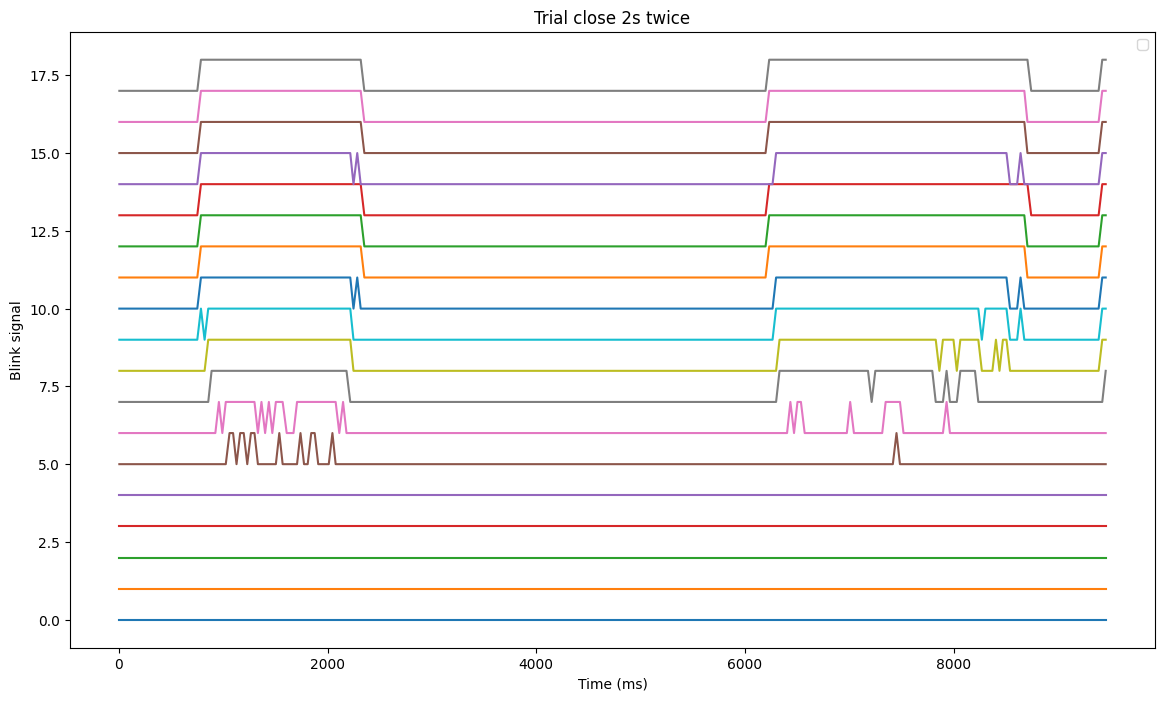

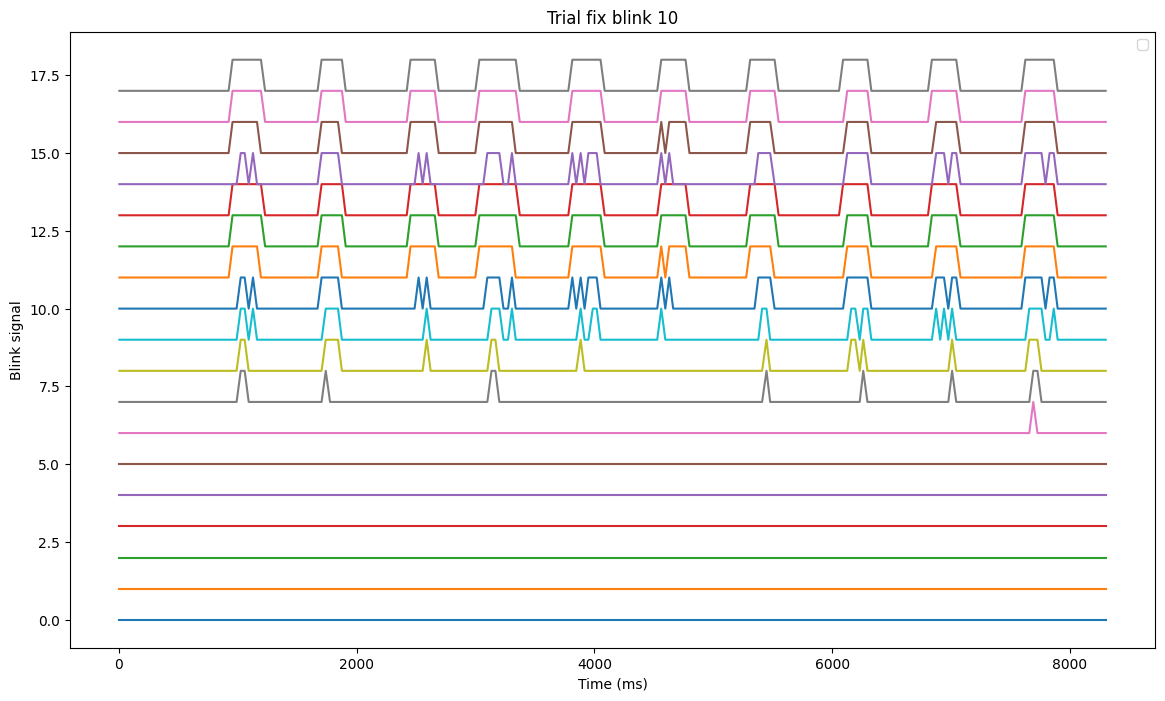

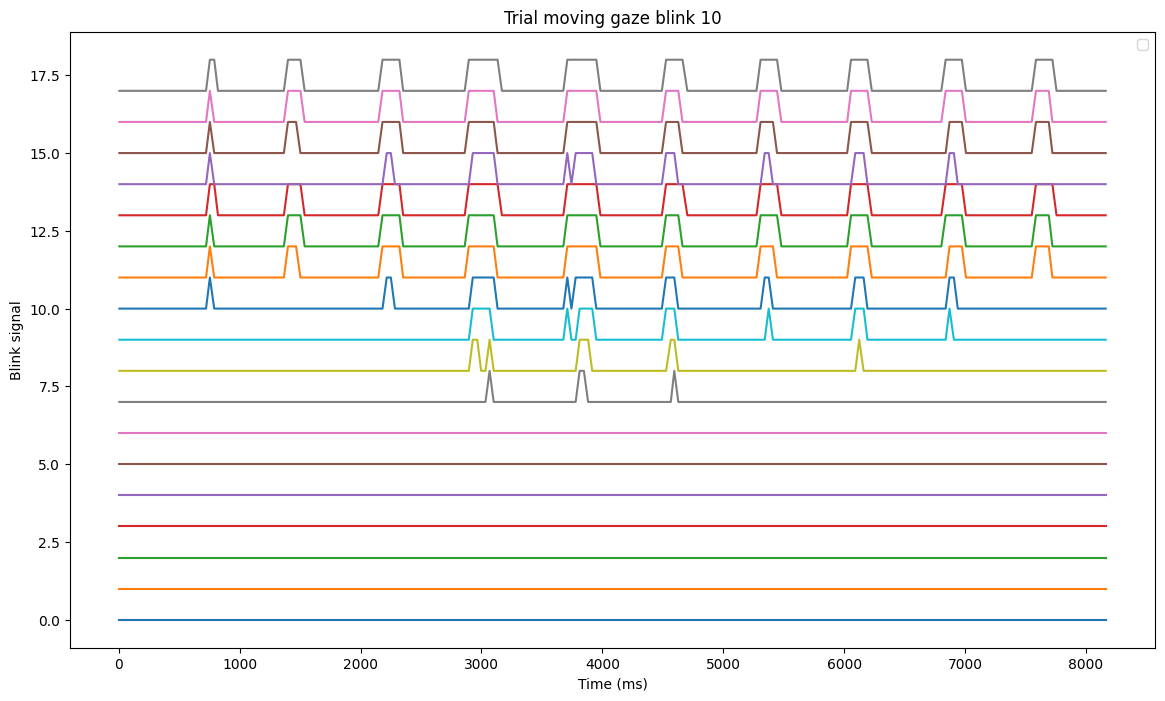

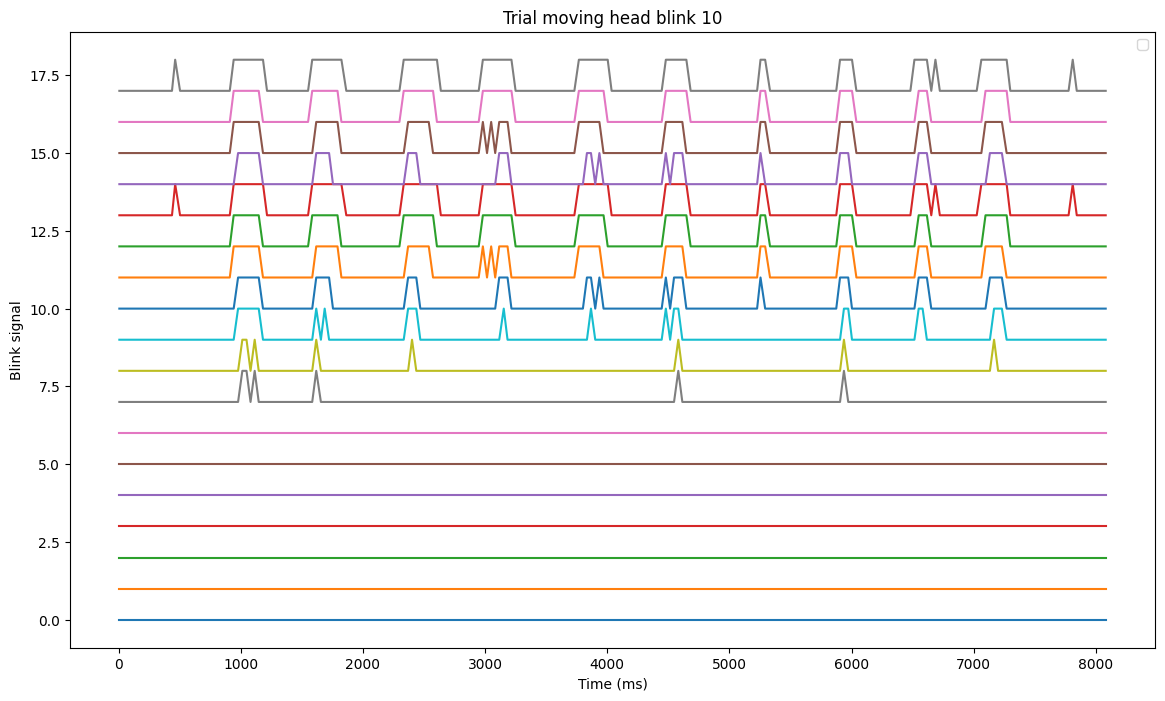

In [32]:
# Define the conditions for the different blink types
# Values for first threshold
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[1]==True)+1)
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[2]==True)+2)
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[3]==True)+3)
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[4]==True)+4)
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[5]==True)+5)
df_webgazer["Blink_sample6"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[6]==True)+6)
df_webgazer["Blink_sample7"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[7]==True)+7)
df_webgazer["Blink_sample8"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[8]==True)+8)
df_webgazer["Blink_sample9"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[9]==True)+9)
df_webgazer["Blink_sample10"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[10]==True)+10)
df_webgazer["Blink_sample11"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[11]==True)+11)
df_webgazer["Blink_sample12"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[12]==True)+12)
df_webgazer["Blink_sample13"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[13]==True)+13)
df_webgazer["Blink_sample14"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[10]==True)+14)
df_webgazer["Blink_sample15"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[11]==True)+15)
df_webgazer["Blink_sample16"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[12]==True)+16)
df_webgazer["Blink_sample17"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[13]==True)+17)


titles = ["Trial blink 5 fast twice",
          "Trial blink 5 slow twice",
          "Trial close 2s twice",
          "Trial fix blink 10",
          "Trial moving gaze blink 10",
          "Trial moving head blink 10"]

# Initialize the plot
plt.figure(figsize=(14, 8))

#df_webgazer[df_webgazer["trial"]==1].plot(x="t", y="Blink_sample", legend=False)
#df_webgazer[df_webgazer["trial"]==1].plot(x="t", y="Blink_sample1", legend=False)
for x in range(0,6):
  plt.figure(figsize=(14, 8))
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample1)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample2)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample3)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample4)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample5)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t , df_webgazer[df_webgazer["trial"]==x+1].Blink_sample6)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t , df_webgazer[df_webgazer["trial"]==x+1].Blink_sample7)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample8)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample9)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample10)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample11)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample12)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample13)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t , df_webgazer[df_webgazer["trial"]==x+1].Blink_sample14)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t , df_webgazer[df_webgazer["trial"]==x+1].Blink_sample15)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t , df_webgazer[df_webgazer["trial"]==x+1].Blink_sample16)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t , df_webgazer[df_webgazer["trial"]==x+1].Blink_sample17)
  plt.title(titles[x])
  plt.xlabel("Time (ms)")
  plt.ylabel("Blink signal")
  plt.legend(loc="upper right")
  plt.show()




# Plot the blink data using different colors for each type

# Add labels and legend
#plt.title("Blink Scatter Plot")
#plt.xlabel("Time (ms)")
#plt.ylabel("Trial")
#plt.legend(loc="upper right")

# Show plot
#plt.show()


In [17]:
df_webgazer

,trial,x,y,t,importantKeypoints,dz,isBlinkByEar,isBlinkByDistance,Blink_sample,Blink_sample1,Blink_sample2,Blink_sample3,Blink_sample4,Blink_sample5,Blink_sample6,Blink_sample7
0,0,0,0,4,"{'noseX': 316.35, 'noseY': 275.68, 'topY': 177...",59.22,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,1,2,3,4,5,6,7
1,1,0,0,58,"{'noseX': 315.52, 'noseY': 277.68, 'topY': 178...",58.69,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,1,2,3,4,5,6,7
2,2,0,0,85,"{'noseX': 315.2, 'noseY': 279.04, 'topY': 179....",58.04,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,1,2,3,4,5,6,7
3,3,0,0,151,"{'noseX': 315.64, 'noseY': 278.25, 'topY': 178...",61.70,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,1,2,3,4,5,6,7
4,4,0,0,185,"{'noseX': 311.98, 'noseY': 279.05, 'topY': 178...",56.96,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,1,2,3,4,5,6,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3705,3705,0,0,129582,"{'noseX': 298.42, 'noseY': 286.12, 'topY': 169...",56.00,"[False, False, False, False, False, False, Fal...","[False, False, True, True, False, False, False...",0,1,2,3,4,5,6,7
3706,3706,0,0,129619,"{'noseX': 297.71, 'noseY': 285.81, 'topY': 168...",52.50,"[False, False, False, False, False, False, Fal...","[False, False, True, True, False, False, False...",0,1,2,3,4,5,6,7
3707,3707,0,0,129654,"{'noseX': 297.33, 'noseY': 285.84, 'topY': 168...",52.72,"[False, False, False, False, False, False, Fal...","[False, False, False, True, False, False, Fals...",0,1,2,3,4,5,6,7
3708,3708,0,0,129693,"{'noseX': 296.9, 'noseY': 286.34, 'topY': 168....",52.35,"[False, False, False, False, False, False, Fal...","[False, False, False, True, False, False, Fals...",0,1,2,3,4,5,6,7


In [ ]:
#GRAFICOS COLORS
# Define the conditions for the different blink types
# Values for first threshold
df_webgazer["Blink_sample"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[1]==True)+1)
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[2]==True)+2)
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[3]==True)+3)
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[4]==True)+4)
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[5]==True)+5)


titles = ["Trial blink 5 fast twice",
          "Trial blink 5 slow twice",
          "Trial close 2s twice",
          "Trial fix blink 10",
          "Trial moving gaze blink 10",
          "Trial moving head blink 10"]

# Initialize the plot
plt.figure(figsize=(14, 8))

#df_webgazer[df_webgazer["trial"]==1].plot(x="t", y="Blink_sample", legend=False)
#df_webgazer[df_webgazer["trial"]==1].plot(x="t", y="Blink_sample1", legend=False)
for x in range(0,6):
  plt.figure(figsize=(14, 8))
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample1)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample2)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample3)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample4)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample5)
  plt.title(titles[x])
  plt.xlabel("Time (ms)")
  plt.ylabel("Blink signal")
  plt.legend(loc="upper right")
  plt.show()




# Plot the blink data using different colors for each type

# Add labels and legend
#plt.title("Blink Scatter Plot")
#plt.xlabel("Time (ms)")
#plt.ylabel("Trial")
#plt.legend(loc="upper right")

# Show plot
#plt.show()


In [ ]:
# Define the conditions for the different blink types
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[5]==True))
df_webgazer[df_webgazer["trial"]==5]

In [ ]:
df_webgazer["isBlinkByEar"] = df_webgazer["isBlinkByEar"].map(
    lambda x: sum([int(i) for i in x])
)
df_webgazer[["t", "isBlinkByEar"]].plot.scatter(x="t", y="isBlinkByEar")

In [ ]:
row = 0
d = {}
df_list_tmp = []

for i, trial in enumerate(df_webgazer["trial"].unique()):
    df_list_tmp.append(df_webgazer.query(f"trial == {trial}"))
    if i > 1:
        d[f"row_{row}"] = pd.concat(df_list_tmp)
        row = row + 1
        i = 0
        df_list_tmp = []

In [ ]:
max_rows = 45
for i in range(20):
    if f"row_{i}" not in d:
        d[f"row_{i}"] = pd.DataFrame()  # Create an empty DataFrame for missing rows
    n_rows = d[f"row_{i}"].shape[0]
    if n_rows < max_rows:
        n_to_add = max_rows - n_rows

        # Pad data to ensure a consistent length
        for _ in range(n_to_add):
            data = {
                "x": [np.nan],
                "y": [np.nan],
                "t": [np.nan],
                "b": [False],
                "sample": [np.nan],
                "trial": [np.nan],
                "trial_type": [""],
            }
            new_row = pd.DataFrame(data)
            d[f"row_{i}"] = pd.concat([d[f"row_{i}"], new_row], ignore_index=True)


In [ ]:
# # Set up the figure
# fig, ax = plt.subplots(figsize=(10, 6))

# # Define colors for trial types
# color_map = {"red": "red", "green": "green"}

# # Iterate through each row (trial)
# for row in range(20):
#     df_row = d[f"row_{row}"]
#     df_row["b"] = df_row["b"].astype(int)

#     # Find the index where 't' is 0
#     zero_index = np.where(df_row["t"] == 0)[0]

#     # Check if there is more than one zero index
#     if len(zero_index) > 1:
#         # Shift 't' values for the second part of the trial
#         df_row["t"].iloc[zero_index[1] :] += df_row["t"].iloc[zero_index[1] - 1]

#     # Plot points based on "b" with black color, y-axis representing the "trial" column
#     ax.scatter(
#         df_row[df_row["b"] == 1]["t"],
#         df_row[df_row["b"] == 1]["trial"],
#         c="black",
#         s=40,
#         alpha=0.8,
#         label="Blinks",
#     )
#     ax.scatter(
#         df_row[(df_row["b"] == 0) & (df_row["t"] > 1000)]["t"],
#         df_row[(df_row["b"] == 0) & (df_row["t"] > 1000)]["trial"],
#         c="green",
#         s=30,
#         alpha=0.2,
#         label="No blink during red",
#     )
#     ax.scatter(
#         df_row[(df_row["b"] == 0) & (df_row["t"] <= 1000)]["t"],
#         df_row[(df_row["b"] == 0) & (df_row["t"] <= 1000)]["trial"],
#         c="red",
#         s=30,
#         alpha=0.2,
#         label="No blink during green",
#     )

# # Set labels and title
# ax.set_xlabel("time (ms)")
# ax.set_ylabel("Trial")

# ax.invert_yaxis()  # Invert the Y-axis